<a href="https://colab.research.google.com/github/juanes0789/ciencia-de-datos-proyecto-de-aula-20261/blob/main/sesiones_practicas/sp_5_Juan_Esteban_Mosquera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Ejercicio 1

In [ ]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Cargar datos
df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nombre        6 non-null      object 
 1   Edad          5 non-null      float64
 2   Ciudad        6 non-null      object 
 3   Ingreso       5 non-null      float64
 4   FechaIngreso  5 non-null      object 
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes


In [ ]:
#Convertir tipo de dato
df['FechaIngreso']=pd.to_datetime(df['FechaIngreso'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Nombre        6 non-null      object        
 1   Edad          5 non-null      float64       
 2   Ciudad        6 non-null      object        
 3   Ingreso       5 non-null      float64       
 4   FechaIngreso  5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 412.0+ bytes


In [ ]:
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,NaN,Medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,NaT
3,None,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12


In [ ]:
#Conteo de valores nulos
df.isna().sum()

,0
Nombre,1
Edad,2
Ciudad,1
Ingreso,2
FechaIngreso,2


In [ ]:
#Descripcion estadistica de variables continuas
df.describe()

,Edad,Ingreso
count,5.000000,5.000000
mean,21.800000,4660.000000
std,15.530615,680.441033
min,-5.000000,3500.000000
25%,25.000000,4700.000000
50%,25.000000,4800.000000
75%,29.000000,5100.000000
max,35.000000,5200.000000


In [ ]:
#Imputacion de variables continuas con la media y categoricas con la moda

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    elif df[col].dtype in ['float64', 'int64']:
      df[col].fillna(df[col].mean(), inplace=True)
    elif df[col].dtype == 'datetime64[ns]':
      df[col].fillna(df[col].median(), inplace=True)



/tmp/ipykernel_5331/3685263550.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_5331/3685263550.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,21.8,Medellín,4800.0,2023-01-05
2,Pedro,35.0,Bogotá,4660.0,2023-01-10
3,Luis,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12


In [ ]:
#Reemplazar registros numericos negativos con la media de la caracteristica
for col in df.columns:
  if df[col].dtype in ['float64', 'int64']:
    mean_val = df[col].mean()
    df.loc[df[col] < 0, col] = mean_val


In [ ]:
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,21.8,Medellín,4800.0,2023-01-05
2,Pedro,35.0,Bogotá,4660.0,2023-01-10
3,Luis,29.0,Medellín,5200.0,2023-01-10
4,Marta,21.8,Cali,5100.0,2023-01-12


El dataframe contiene un total de 5 caracteristicas y 7 registros de los cuales algunos eran nulos o tenian inconsistencias como fue el caso de la edad -5 la cual no tenia sentido y se imputó en su lugar la media de las edades. Tambien la caracteristica fechas era inicialmente del tipo Object y se convirtio a datetime para su correcto manejo como fecha. Luego de identificar los datos faltantes se realizo la imputacion a traves de la moda y la media para las variables categoricas y numericas respectivamente mientras que para la fecha se usó la mediana. Finalmente el Dataset quedó limpio y consistente para su utilizacion.

##Ejercicio 2

In [ ]:
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

In [ ]:
df.head(7)

,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


**¿Cuál es el total de registros originales?**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             7 non-null      int64 
 1   Nombre         7 non-null      object
 2   Edad           7 non-null      int64 
 3   Ciudad         7 non-null      object
 4   FechaRegistro  7 non-null      object
dtypes: int64(2), object(3)
memory usage: 412.0+ bytes


El metodo `info()` permite conocer el numero de registros, en este caso son 7.

**¿Cuáles y cuántos son los duplicados exactos?**


In [ ]:
display(df[df.duplicated(keep=False)])
print(f'Hay {df.duplicated().sum()} duplicados')

,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15


Hay 2 duplicados


**¿Cuáles y cuántos son los duplicados por varias columnas?**

In [ ]:
display(df[df.duplicated(keep=False, subset=['Nombre', 'Ciudad'])])
print(f'Hay {df.duplicated(subset=["Nombre", "Ciudad"]).sum()} duplicados')


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


Hay 3 duplicados


**¿Cuántos registros debes eliminar?**

En el Dataset hay 4 registros identicos, por tanto hay que eliminar solo 2 registros.

**¿Cuántos registros quedan después de la limpieza?**

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 6
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             5 non-null      int64 
 1   Nombre         5 non-null      object
 2   Edad           5 non-null      int64 
 3   Ciudad         5 non-null      object
 4   FechaRegistro  5 non-null      object
dtypes: int64(2), object(3)
memory usage: 240.0+ bytes


Quedan 5 registros luego de eliminar los duplicados

##Ejercicio 3

In [ ]:
df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

In [ ]:
# Install fuzzywuzzy for robust string matching
!pip install fuzzywuzzy python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.2 MB/s eta 0:00:00


Para reemplazar errores tipográficos de manera más robusta, utilizaremos la biblioteca `fuzzywuzzy`. Esta técnica permite encontrar la coincidencia más cercana entre los nombres de las ciudades en el DataFrame y una lista de nombres correctos, basándose en la similitud de las cadenas de texto. Esto es especialmente útil cuando la cantidad de datos es grande y no se conocen todos los posibles errores de antemano.

In [ ]:
# Importar librerías necesarias para fuzzy matching
from fuzzywuzzy import process
from fuzzywuzzy import fuzz
import pandas as pd
import unicodedata

# Definir una lista de nombres de ciudades correctos (en minúsculas para la comparación)
correct_cities = ['bogota', 'cali', 'medellin']

# Función para corregir la ciudad usando fuzzy matching
def correct_city_name(city):
    if pd.isna(city): # Manejar valores NaN
        return city
    # Encontrar la mejor coincidencia con un umbral de similitud (ej. 80)
    match = process.extractOne(city, correct_cities, scorer=fuzz.ratio)
    if match and match[1] >= 80: # Si la similitud es >= 80%, usar la corrección
        return match[0].capitalize() # Capitalizar la ciudad corregida
    else:
        return str(city).capitalize() # Si no hay buena coincidencia, mantener el original y capitalizar

# Aplicar la corrección después de normalizar a minúsculas y quitar acentos
df['Ciudad'] = df['Ciudad'].str.lower() # Convertir a minúsculas antes de procesar
df['Ciudad'] = df['Ciudad'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8'))
df['Ciudad'] = df['Ciudad'].apply(correct_city_name)



In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head(len(df))

,Ciudad
0,Bogota
7,Cali
9,Medellin


## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).

    -- **MCAR**: Ya que la ausencia del dato no se debe a su relacion con alguna otra variable sin poder explicar la razón.
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

    -- **MAR**: En este caso la asuencia de los datos en Horas de estudio se puede explicar usando la informacion observada en relación con la caracteristica promedio.
  
   - **Escenario 3.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.

    -- **MAR**: Los datos faltantes estan relacionados con la caracteristica genero por lo que se puede explicar a traves de su relación.
   - **Escenario 4.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.

    -- **MNAR**: La ausencia está relacionada con la misma caracteristica, hay una tendencia que no depende de otras variables.
   

##Ejercicio 5

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

In [ ]:
df

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.0,2909818.0,7
1,46,2.27,NaN,3031785.0,7
2,32,NaN,30.0,5283302.0,9
3,25,3.15,14.0,NaN,3
4,38,4.95,7.0,3525928.0,7
5,56,NaN,13.0,4653339.0,1
6,36,4.58,22.0,NaN,4
7,40,4.04,NaN,1879111.0,4
8,28,NaN,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7


In [ ]:
df.isna().sum() / len(df) * 100

,0
Edad,0.000000
Promedio,13.333333
Horas_estudio,13.333333
Ingreso_familiar,10.000000
Semestres_cursados,0.000000


En el dataset las variables con mayor proporción de datos faltantes son 'Horas_Estudio' y Promedio, ambas con 13.3%. Pero eso no es evidencia fuerte de que estén relacionadas, por lo que no podemos concluir su relación.

### Imputación de valores faltantes con KNN

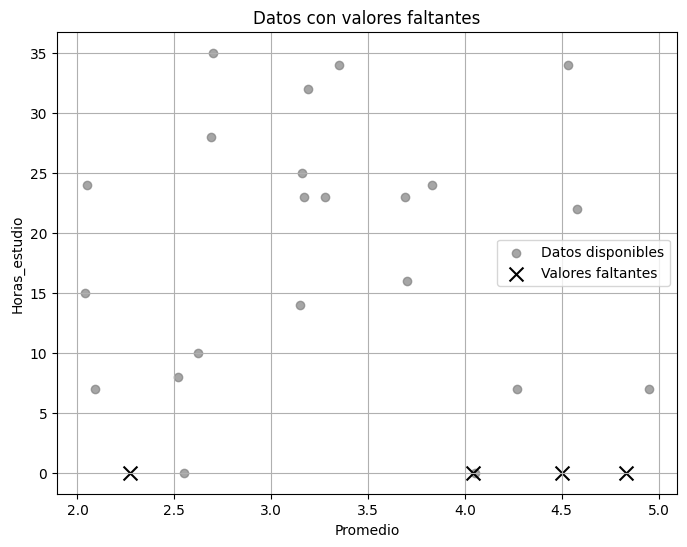

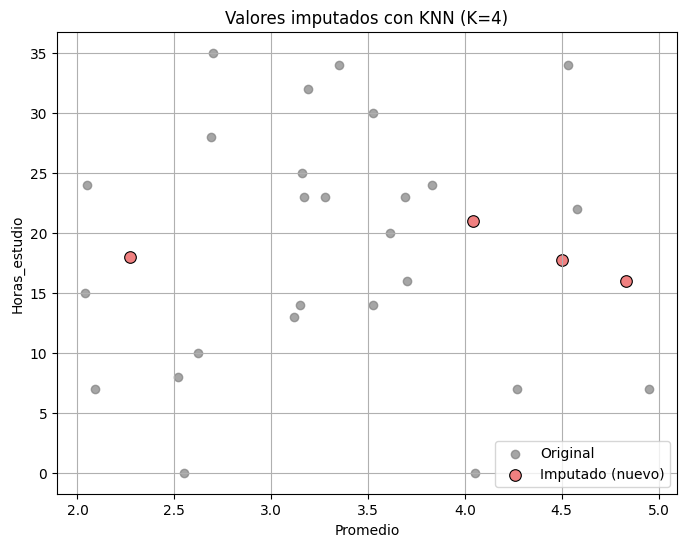

Valores faltantes antes de imputar:
Edad                  0
Promedio              4
Horas_estudio         4
Ingreso_familiar      3
Semestres_cursados    0
dtype: int64

Valores faltantes después de imputar:
Edad                  0
Promedio              0
Horas_estudio         0
Ingreso_familiar      0
Semestres_cursados    0
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

# Imputación con KNN
imputer = KNNImputer(n_neighbors=4)
data_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


# -------- Máscara de valores imputados --------
mask_missing = df["Horas_estudio"].isnull()

# figure
plt.figure(figsize=(8,6))
plt.scatter(df["Promedio"], df["Horas_estudio"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(df.loc[mask_missing, "Promedio"],
            [0]*mask_missing.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Promedio")
plt.ylabel("Horas_estudio")
plt.title("Datos con valores faltantes")
plt.legend()
plt.grid(True)
plt.show()

# figure
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing, "Promedio"],
            data_imputed.loc[~mask_missing, "Horas_estudio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing, "Promedio"],
            data_imputed.loc[mask_missing, "Horas_estudio"],
            color="lightcoral", edgecolors="black", linewidths=0.8,
            s=70, label="Imputado (nuevo)")

plt.xlabel("Promedio")
plt.ylabel("Horas_estudio")
plt.title("Valores imputados con KNN (K=4)")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar:")
print(df.isnull().sum())

print("\nValores faltantes después de imputar:")
print(data_imputed.isnull().sum())


### Imputación de valores faltantes con Regresión

Ahora, realizaremos la imputación utilizando un modelo de regresión. Para cada columna con valores faltantes, construiremos un modelo que prediga esos valores basándose en las otras características del DataFrame. Usaremos `RandomForestRegressor` para esta tarea.

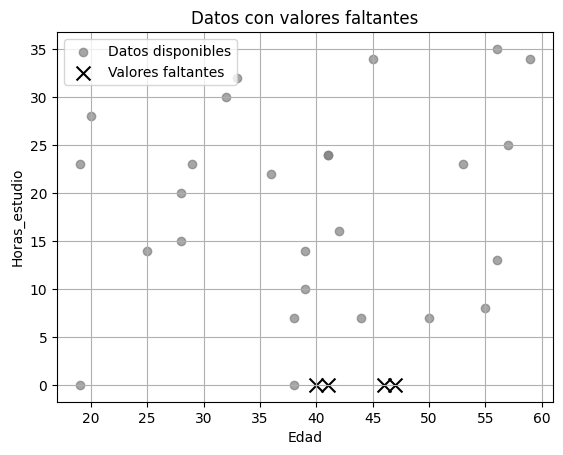

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


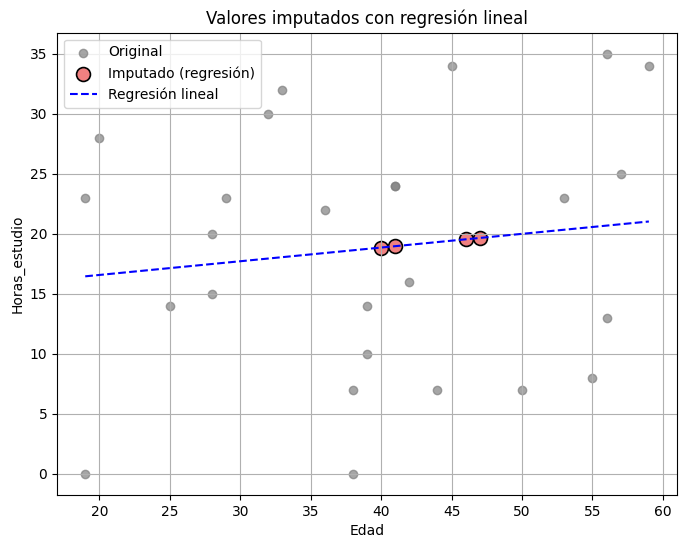

Valores faltantes antes de imputar:
Edad                  0
Promedio              4
Horas_estudio         4
Ingreso_familiar      3
Semestres_cursados    0
dtype: int64

Valores faltantes después de imputar:
Edad                  0
Promedio              4
Horas_estudio         0
Ingreso_familiar      3
Semestres_cursados    0
dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression



# Separar datos completos y faltantes
mask_missing = df["Horas_estudio"].isnull()
X_train = df.loc[~mask_missing, ["Edad"]]
y_train = df.loc[~mask_missing, "Horas_estudio"]

X_missing = df.loc[mask_missing, ["Edad"]]

# regresión lineal
reg = LinearRegression()
reg.fit(X_train, y_train)

# valores faltantes
data_imputed = df.copy()
data_imputed.loc[mask_missing, "Horas_estudio"] = reg.predict(X_missing)

#plt.figure(figsize=(8,6))
plt.scatter(df["Edad"], df["Horas_estudio"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(df.loc[mask_missing, "Edad"],
            [0]*mask_missing.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Edad")
plt.ylabel("Horas_estudio")
plt.title("Datos con valores faltantes")
plt.legend()
plt.grid(True)
plt.show()

#
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing, "Edad"],
            data_imputed.loc[~mask_missing, "Horas_estudio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing, "Edad"],
            data_imputed.loc[mask_missing, "Horas_estudio"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (regresión)")
x_line = np.linspace(df["Edad"].min(), df["Edad"].max(), 100).reshape(-1,1)
y_line = reg.predict(x_line)
plt.plot(x_line, y_line, color="blue", linestyle="--", label="Regresión lineal")

plt.xlabel("Edad")
plt.ylabel("Horas_estudio")
plt.title("Valores imputados con regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

# -------- Verificación --------
print("Valores faltantes antes de imputar:")
print(df.isnull().sum())

print("\nValores faltantes después de imputar:")
print(data_imputed.isnull().sum())


Luego de analizar las imputaciones de los valores faltantes en knn se puede observar que la calidad y preservación de la naturaleza de los datos varia dependiendo del numero de vecinos, un numero muy bajo da casi el mismo resultado del metodo de regresión lineal, pero con un numero óptimo como en este caso 4 se ve una suavidad en los datos que sigue la naturaleza de los datos existentes ya que toma los vecinos que realmente estan cerca sin pasarse a otros mas alejados por escoger un numero no ideal.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
  'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
  'Ventas': np.round(np.random.uniform(100, 500, n), 2),
  'Inventario': np.random.randint(10, 100, n),
  'Clientes': np.random.randint(1, 50, n)
})

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)

In [ ]:
df


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,NaN
2,2023-01-03,392.80,30.0,NaN
3,2023-01-04,NaN,82.0,44.0
4,2023-01-05,NaN,48.0,34.0
5,2023-01-06,NaN,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,NaN,14.0
8,2023-01-09,340.45,NaN,31.0
9,2023-01-10,383.23,23.0,48.0


### Análisis de Datos Faltantes en Series Temporales

**¿Qué variables presentan datos faltantes consecutivos?**

Al analizar el DataFrame `df`:
*   **Ventas**: Presenta datos faltantes consecutivos en los índices 3, 4, 5 y también en 12, 13.
*   **Inventario**: Presenta datos faltantes consecutivos en los índices 7, 8.
*   **Clientes**: Presenta datos faltantes consecutivos en los índices 1, 2 y también en 18, 19.

**¿Por qué este tipo de patrón es relevante en series temporales?**

En series temporales, los datos faltantes consecutivos indican períodos prolongados sin observaciones. Esto es crucial porque:
1.  **Imputación**: Métodos simples como LOCF o NOCB pueden volverse menos precisos, ya que la 'última' o 'próxima' observación conocida podría estar muy distante en el tiempo, perdiendo relevancia.
2.  **Análisis de Tendencias/Estacionalidad**: Grandes huecos pueden distorsionar o dificultar la identificación de tendencias, estacionalidad o ciclos a corto plazo.
3.  **Modelado**: Los modelos de pronóstico pueden tener dificultades para aprender patrones en segmentos con muchos datos faltantes consecutivos, lo que afecta la precisión de las predicciones.

**¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?**

El orden de los datos es **fundamental** para la imputación LOCF (Last Observation Carried Forward) y NOCB (Next Observation Carried Backward). Si el DataFrame no está ordenado cronológicamente (o según el índice de la serie temporal), estas imputaciones rellenarían los valores faltantes con observaciones **incorrectas** que no son verdaderamente la 'última' o 'próxima' en el tiempo real, llevando a resultados erróneos y un análisis sesgado. Dado que el DataFrame `df` ya fue ordenado por la columna 'Fecha', podemos proceder con confianza.

### Imputación de Valores Faltantes con LOCF y NOCB

In [ ]:
# Imputación usando LOCF (Last Observation Carried Forward)
df_locf_imputed = df.ffill()

print("DataFrame después de imputación LOCF:")
print(df_locf_imputed.isnull().sum())
display(df_locf_imputed.head(10))

# Imputación usando NOCB (Next Observation Carried Backward)
df_nocb_imputed = df.bfill()

print("\nDataFrame después de imputación NOCB:")
print(df_nocb_imputed.isnull().sum())
display(df_nocb_imputed.head(10))

DataFrame después de imputación LOCF:
Fecha         0
Ventas        0
Inventario    0
Clientes      0
dtype: int64


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,29.0
2,2023-01-03,392.80,30.0,29.0
3,2023-01-04,392.80,82.0,44.0
4,2023-01-05,392.80,48.0,34.0
5,2023-01-06,392.80,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,13.0,14.0
8,2023-01-09,340.45,13.0,31.0
9,2023-01-10,383.23,23.0,48.0



DataFrame después de imputación NOCB:
Fecha         0
Ventas        0
Inventario    0
Clientes      0
dtype: int64


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,44.0
2,2023-01-03,392.80,30.0,44.0
3,2023-01-04,123.23,82.0,44.0
4,2023-01-05,123.23,48.0,34.0
5,2023-01-06,123.23,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,23.0,14.0
8,2023-01-09,340.45,23.0,31.0
9,2023-01-10,383.23,23.0,48.0


### Visualización de Imputación en Series Temporales

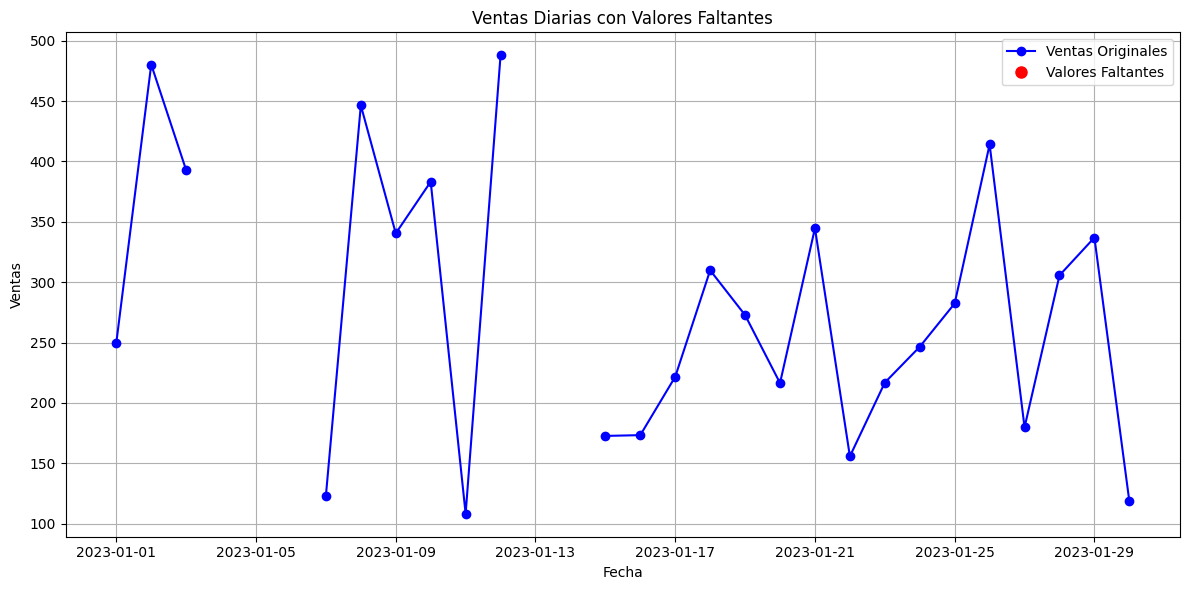

In [ ]:
import matplotlib.pyplot as plt

# --- Visualización de la columna 'Ventas' con valores faltantes ---
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], df['Ventas'], marker='o', linestyle='-', color='blue', label='Ventas Originales')
plt.plot(df['Fecha'][df['Ventas'].isnull()], df['Ventas'][df['Ventas'].isnull()], 'ro', markersize=8, label='Valores Faltantes')
plt.title('Ventas Diarias con Valores Faltantes')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

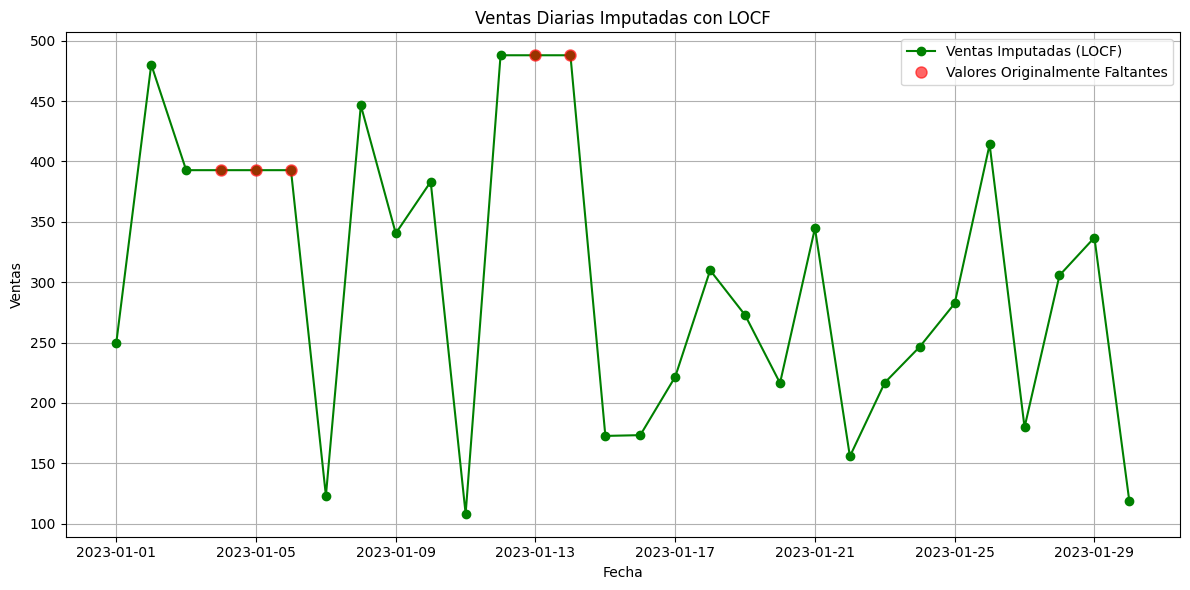

In [ ]:
# --- Visualización de la columna 'Ventas' después de imputación LOCF ---
plt.figure(figsize=(12, 6))
plt.plot(df_locf_imputed['Fecha'], df_locf_imputed['Ventas'], marker='o', linestyle='-', color='green', label='Ventas Imputadas (LOCF)')
plt.plot(df['Fecha'][df['Ventas'].isnull()], df_locf_imputed['Ventas'][df['Ventas'].isnull()], 'ro', markersize=8, alpha=0.6, label='Valores Originalmente Faltantes')
plt.title('Ventas Diarias Imputadas con LOCF')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

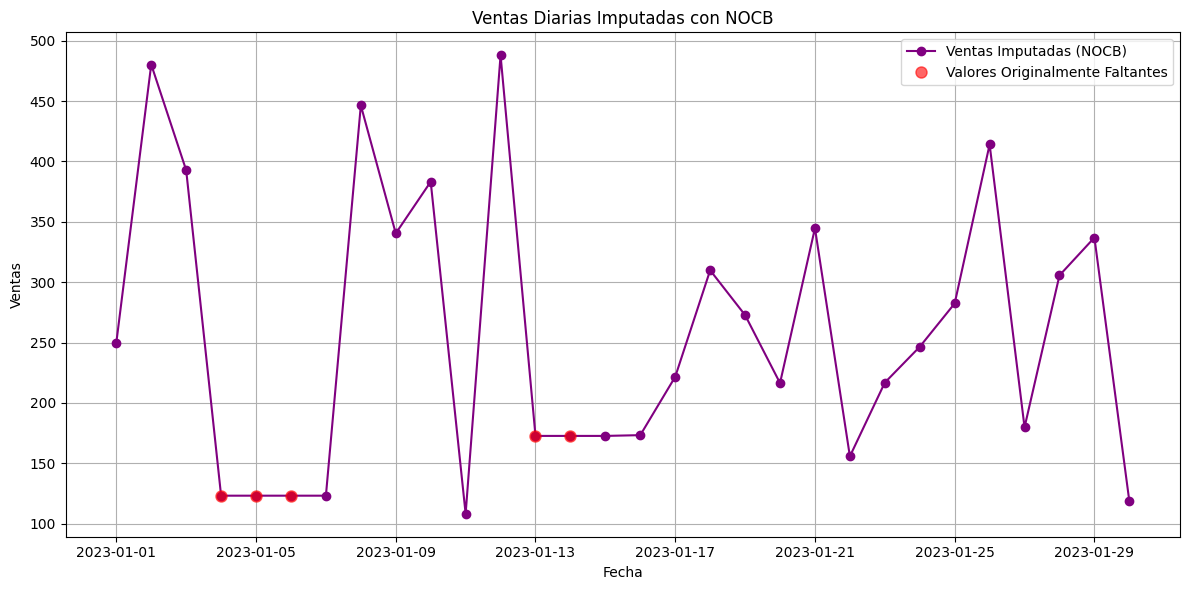

In [ ]:
# --- Visualización de la columna 'Ventas' después de imputación NOCB ---
plt.figure(figsize=(12, 6))
plt.plot(df_nocb_imputed['Fecha'], df_nocb_imputed['Ventas'], marker='o', linestyle='-', color='purple', label='Ventas Imputadas (NOCB)')
plt.plot(df['Fecha'][df['Ventas'].isnull()], df_nocb_imputed['Ventas'][df['Ventas'].isnull()], 'ro', markersize=8, alpha=0.6, label='Valores Originalmente Faltantes')
plt.title('Ventas Diarias Imputadas con NOCB')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Método Más Apropiado


Para este caso específico de datos de ventas, inventario y clientes en series temporales, el método **LOCF (Last Observation Carried Forward)** es generalmente el más apropiado.
Es común que la actividad de ventas de un día anterior sea la mejor estimación para un día sin registro, asumiendo una continuidad hasta que se observe un nuevo dato. El nivel de inventario de un día suele mantenerse hasta que hay una nueva entrada o salida significativa, por lo que la última observación es una buena aproximación. El número de clientes podría seguir un patrón similar, donde la cantidad del día anterior es una base razonable.

El método NOCB (Next Observation Carried Backward) podría ser útil si se tuviera información futura que explicara el valor faltante (por ejemplo, si se sabe que un evento futuro afectará un período anterior).